<a href="https://colab.research.google.com/github/Vihhycherezass/Bank-Customer-Churn-Prediction/blob/main/Bank_Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier, StackingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, recall_score, f1_score, accuracy_score, precision_score, precision_recall_curve, auc

import warnings
plt.style.use('seaborn-v0_8') #Применяем стиль отображения графиков matplotlib
sns.set_palette('husl') #Применяем цветовую палитру для графиков sns
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = [14,6]

In [ ]:
df = pd.read_csv('./Customer-Churn-Records.csv')

#Первичный осмотр данных

In [ ]:
print("Размер датасета: ", df.shape)
print("Превые пять строк: ")
df.head()

Размер датасета:  (10000, 18)
Превые пять строк: 


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [ ]:
print("Информация о колонках: ")
df.info()

Информация о колонках: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-

In [ ]:
print("Статистическое описание числовых признаков: ")
df.describe()

Статистическое описание числовых признаков: 


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [ ]:
print("Пропущенные значения: ")
print(df.isnull().sum())

Пропущенные значения: 
RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64


Удаляем бесполезные колонки из датасета\
RowNumber - просто номер строки\
Surname - фамилия пользователя,не влияет на отток\
CustomerId - идентификатор пользователя, тоже никак не влияет на отток

In [ ]:
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df_clean = df.drop(columns=columns_to_drop)
print("Оставшиеся колонки, которые нам понадобяться:")
for column in df_clean.columns.tolist():
  print(f"-{column}")

Оставшиеся колонки, которые нам понадобяться:
-CreditScore
-Geography
-Gender
-Age
-Tenure
-Balance
-NumOfProducts
-HasCrCard
-IsActiveMember
-EstimatedSalary
-Exited
-Complain
-Satisfaction Score
-Card Type
-Point Earned


#Анализ целевой переменной

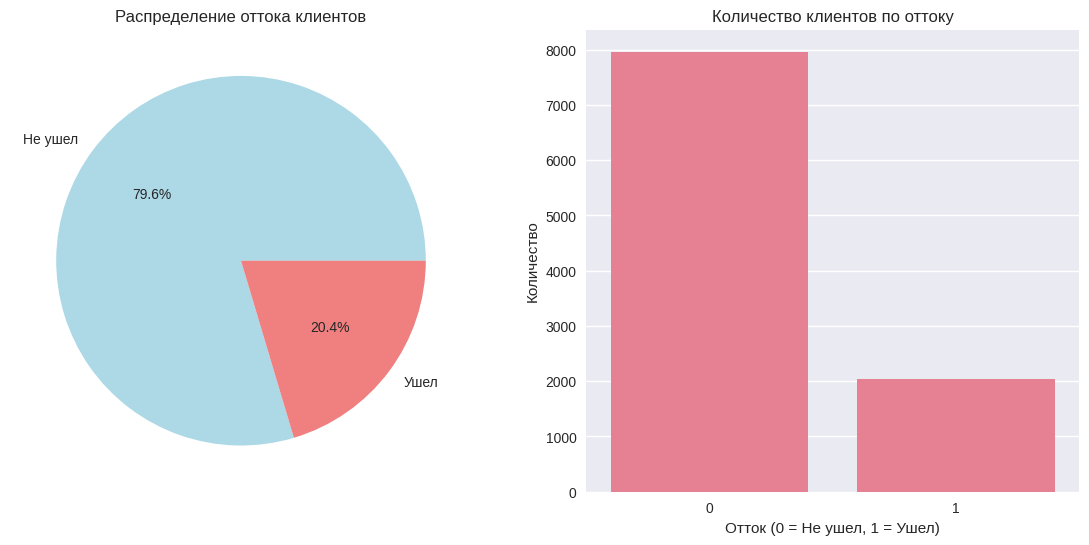

Статистика оттока: 
Не ушли: 7962 клиентов (79.6%)
Ушли: 2038 клиентов (20.4%)


In [ ]:
plt.subplot(1, 2, 1)
churn_counts = df_clean['Exited'].value_counts()
plt.pie(churn_counts.values, labels=['Не ушел', 'Ушел'], autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
plt.title('Распределение оттока клиентов')

plt.subplot(1, 2, 2)
sns.countplot(data=df_clean, x='Exited')
plt.title("Количество клиентов по оттоку")
plt.xlabel("Отток (0 = Не ушел, 1 = Ушел)")
plt.ylabel("Количество")
plt.show()

print("Статистика оттока: ")
print(f"Не ушли: {churn_counts[0]} клиентов ({churn_counts[0]/len(df_clean) * 100:.1f}%)")
print(f"Ушли: {churn_counts[1]} клиентов ({churn_counts[1]/len(df_clean) * 100:.1f}%)")

#EDA - категориальные признаки

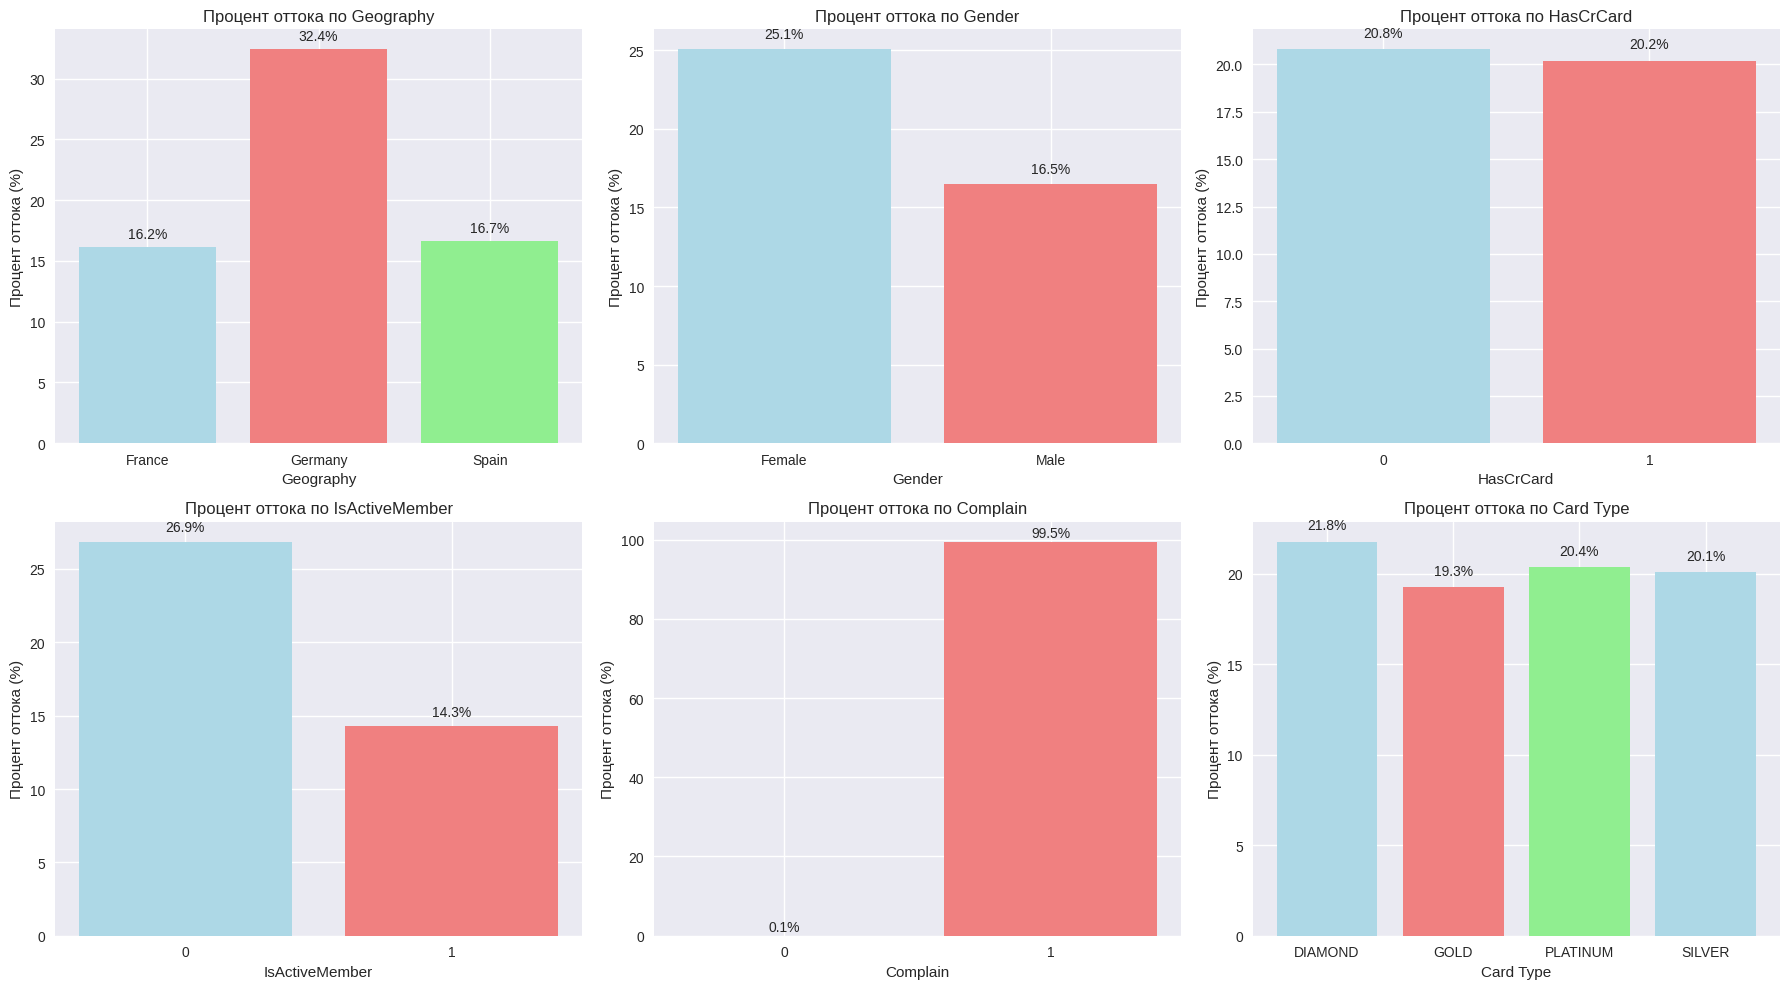

In [ ]:
categorical_columns = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'Complain', 'Card Type']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, col in enumerate(categorical_columns):
  churn_rate = df_clean.groupby(col)['Exited'].mean() * 100

  bars = axes[i].bar(range(len(churn_rate)), churn_rate.values, color=['lightblue', 'lightcoral', 'lightgreen'])
  axes[i].set_title(f"Процент оттока по {col}")
  axes[i].set_xlabel(col)
  axes[i].set_ylabel("Процент оттока (%)")
  axes[i].set_xticks(range(len(churn_rate)))
  axes[i].set_xticklabels(churn_rate.index)

  for bar, value in zip(bars, churn_rate.values):
    axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{value:.1f}%', ha='center', va='bottom')
plt.tight_layout()
plt.show()

Признак Complain сильно коррелирует с целевой переменной. В данном датасете не сказано когда пользователь оставляет жалобы, после ухода или же перед уходом. Так как это моя первая такая работа с сильной корреляцией между признаком и целевой переменной я хочу попробовать использовать ее в обучении.

#EDA - числовые признаки

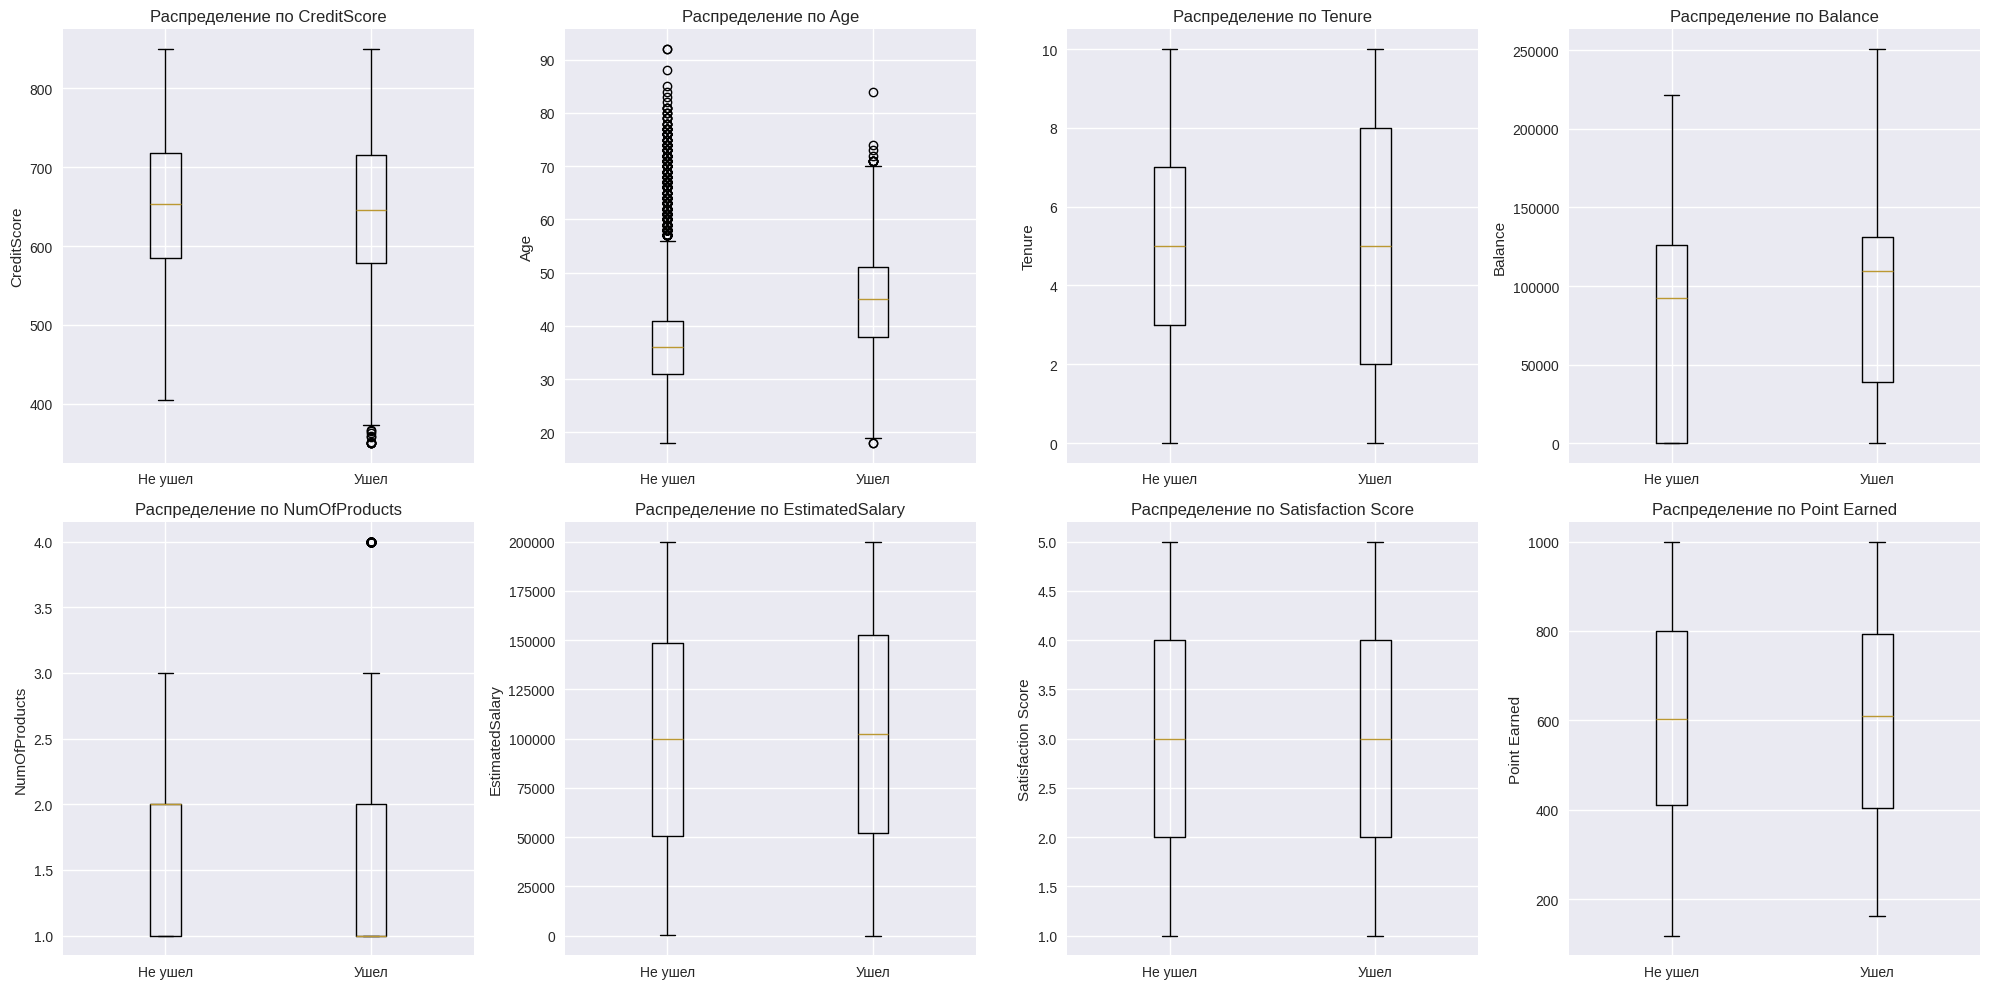

In [ ]:
numerical_columns = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Satisfaction Score', 'Point Earned']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, col in enumerate(numerical_columns):
  data_to_plot=[df_clean[df_clean['Exited'] == 0][col],
                df_clean[df_clean['Exited'] == 1][col]]
  axes[i].boxplot(data_to_plot, labels=['Не ушел', 'Ушел'])
  axes[i].set_title(f'Распределение по {col}')
  axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

#Вывод по графикам
После анализа графиков можно выделить основные признаки, которые имеют большее значение для оттока по сравнению с другими:\
Geography - люди, живущие в Германии чаще всего покидают банк\
Gender - Женщины чаще покидают банк\
HasCrCart - не сильно влияет на отток, так как разница небольшая\
IsActiveMember - чаще уходят люди, не пользующиеся услугами банка\
Complain - 99.5% ушедших оставляли жалобы на банк\
Card Type - тип карты сильно не влияет на отток клиентов\
CreditScore - так же не сильно влияет на отток\
Age - в основном уходят люди в возрасте от 36 до 51 лет. Так же правый ящик выше левого, это означает, что ушедшие имеют меньшее значение\
Tenure - медиана одинаковая, то есть пользование услугами банка около 5 лет\
Balance - влияет на отток, медианы не на одном уровне, средний баланс значительно отличется\
NumOfProducts - чаще уходят люди с одним продуктом банка, а остаются пользователи с двумя продуктами\
EstimatedSalary - не сильно влияет на отток\
Satisfaction Score - медианы на одном уровне, уровень удовлетворения у ушедших/неушедших пользователь одинаковый\
Point Earned - так де не сильно влияет на отток, так как медианы промерно на одном уровне


#Features Engineering
Это процесс создания новых признаков на существующих данных или преобразование существующих признаков для того, чтобы помочь модели лучше понимать закономерность в данных.


#Финансовые метрики

In [ ]:
df_clean['Balance_To_Salary_Ratio'] = df_clean['Balance'] / (df_clean['EstimatedSalary'] + 1) #Соотношение баланса в банке и предпологаем зарплатой пользователя
df_clean['Salary_Per_Product'] = df_clean['EstimatedSalary'] / (df_clean['NumOfProducts'] + 1) #Предпологаемая зарплата пользователя на единицу продукта
df_clean['Financial_Health'] = (df_clean['Balance'] + df_clean['EstimatedSalary']) / 100000 #Индекс финансового положения клиента(финансоустойчивый клиент/клиент с ограниченными финансовыми ресурсами)

#Поведенческие метрики

In [ ]:
df_clean['Engagement_Score'] = ( #Оценка вовлеченности клиента
    df_clean['IsActiveMember'] +
    df_clean['HasCrCard'] +
    (df_clean['Point Earned'] / 500) #Нормализуем данные о заработанных баллах пользователя
)

df_clean['Complaint_Intensity'] = df_clean['Complain'] / (df_clean['Tenure'] + 1) #Интенсивность жалоб
df_clean['Satisfaction_Engagment'] = df_clean['Satisfaction Score'] * df_clean['IsActiveMember'] #Удовлетворенность вовлеченности

#Демографические признаки

In [ ]:
df_clean['Age_Tenure_Interaction'] = df_clean['Age'] * df_clean['Tenure'] #Взвешенный стаж клиента
df_clean['Credit_Age_Ratio'] = df_clean['CreditScore'] / df_clean['Age'] #Соотношение крединог рейтинга и возраста пользователя

#Сегментация клиентов на основе данных

In [ ]:
#Функция для сегментации клиентов
def create_customer_segment(row):
  if row['Balance'] > 100000 and row['IsActiveMember'] == 1:
    return 'premium_acrive'
  elif row['NumOfProducts'] >= 3:
    return 'multi_product'
  elif row['Tenure'] > 2:
    return 'new_customer'
  elif row['Age'] > 60:
    return 'senior'
  else:
    return 'standard'
df_clean['Customer_Segment'] = df_clean.apply(create_customer_segment, axis=1)

#Риск профили

In [ ]:
df_clean['Risk_Score'] = ((1000 - df_clean['CreditScore']) / 100) * (df_clean['Complain'] + 1)
df_clean['Loyalty_Score'] = (df_clean['Tenure'] * df_clean['IsActiveMember'] * (df_clean['Satisfaction Score'] / 5) * (df_clean['Point Earned']  / 1000))

print(f"Все признаки на данный момент: {df_clean.columns}")

Все признаки на данный момент: Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'Complain', 'Satisfaction Score', 'Card Type', 'Point Earned',
       'Balance_To_Salary_Ratio', 'Salary_Per_Product', 'Financial_Health',
       'Engagement_Score', 'Complaint_Intensity', 'Satisfaction_Engagment',
       'Age_Tenure_Interaction', 'Credit_Age_Ratio', 'Customer_Segment',
       'Risk_Score', 'Loyalty_Score'],
      dtype='object')


#Анализ новых признаков

In [ ]:
new_features = ['Balance_To_Salary_Ratio', 'Engagement_Score', 'Complaint_Intensity', 'Risk_Score', 'Loyalty_Score', 'Customer_Segment']

print("Статичстика новых признаков:")
for feature in new_features:
  if feature != 'Customer_Segment':
    stayed_mean = df_clean[df_clean['Exited'] == 0][feature].mean() # Среднее значение признака оставшихся людей
    left_mean = df_clean[df_clean['Exited'] == 1][feature].mean() # Среднее значение признака ушедших людей
    diff_pct = ((left_mean - stayed_mean) / stayed_mean) * 100 # Разница в процентах

    print(f"{feature:25} | Не ушли: {stayed_mean:7.2f} | Ушли: {left_mean:7.2f} | Разница: {diff_pct:+.1f}%")

    if abs(diff_pct) > 10:
      print(' ' * 25 + ' Важный признак')
  else:
    segment_churn = df_clean.groupby('Customer_Segment')['Exited'].mean()
    print(f"Процент оттока по сегментам: ")
    for segment, churn_rate in segment_churn.items():
      print(f" {segment:22}: {churn_rate * 100:5.1f}%")

Статичстика новых признаков:
Balance_To_Salary_Ratio   | Не ушли:    2.48 | Ушли:    8.92 | Разница: +260.3%
                          Важный признак
Engagement_Score          | Не ушли:    2.48 | Ушли:    2.27 | Разница: -8.4%
Complaint_Intensity       | Не ушли:    0.00 | Ушли:    0.25 | Разница: +92892.0%
                          Важный признак
Risk_Score                | Не ушли:    3.49 | Ушли:    7.09 | Разница: +103.2%
                          Важный признак
Loyalty_Score             | Не ушли:    1.01 | Ушли:    0.61 | Разница: -39.2%
                          Важный признак
Процент оттока по сегментам: 
 multi_product         :  84.2%
 new_customer          :  18.3%
 premium_acrive        :  18.0%
 senior                :  28.4%
 standard              :  20.4%


После анализа статистики новых признаков можно заметить проблемы:\
Complaint_Intensity - слишком большая разница в 92892%, это может происходить из-за того, что complain сильно коррелирует с целевой переменной, complain = 1 часто означает, что пользователь уже ушел или собирается уйти.\
Balance_To_Salary_Ration - так же большая разница. Слишком большой разброс из-за деления на ноль.\
high_risk_dissatisfied = 99,7% - почти 100% отток, признак переобучения. Проблема из-за complain, который почти всегда означает, что клиент ушел.

In [ ]:
print("Анализ Balance_To_Salary_Ratio:")
print(f"Минимум: {df_clean['Balance_To_Salary_Ratio'].min()}")
print(f"Максимум: {df_clean['Balance_To_Salary_Ratio'].max()}")
print(f"Медиана: {df_clean['Balance_To_Salary_Ratio'].median()}")

Анализ Balance_To_Salary_Ratio:
Минимум: 0.0
Максимум: 9770.883147853736
Медиана: 0.7469975565191619


In [ ]:
df_clean['Balance_To_Salary_Ratio'] = df_clean['Balance'] / (df_clean['EstimatedSalary'] + 1000)
df_clean['Balance_To_Salary_Ratio'] = np.clip(df_clean['Balance_To_Salary_Ratio'], 0, 10) # Ограничиваем значение от 0 до 10, чтобы значение не был отрицательным и больше 10, так как редко бывает такое, что у пользователя в банке лежит больше 10 зарплат, что может привести к выбросам, если зарплат больше > 10

In [ ]:
df_clean = df_clean.drop('Complaint_Intensity', axis=1) # Удаляем проблемный признак
df_clean['Tenure_Engagement'] = df_clean['Tenure'] * df_clean['IsActiveMember']
df_clean['Product_Value_Ratio'] = df_clean['NumOfProducts'] * (df_clean['Balance'] / 10000)
df_clean['Salary_Age_Ratio'] = df_clean['EstimatedSalary'] / df_clean['Age']

#Обновленный анализ новых признаков

In [ ]:
new_features_updated = ['Balance_To_Salary_Ratio', 'Engagement_Score', 'Risk_Score', 'Loyalty_Score', 'Tenure_Engagement', 'Product_Value_Ratio', 'Salary_Age_Ratio', 'Customer_Segment']

for feature in new_features_updated:
  if feature != 'Customer_Segment':
    stayed_mean = df_clean[df_clean['Exited'] == 0][feature].mean()
    left_mean = df_clean[df_clean['Exited'] == 1][feature].mean()
    diff_pct = ((left_mean - stayed_mean) / stayed_mean) * 100

    print(f'{feature:25} | Не ушли: {stayed_mean:7.2f} | Ушли: {left_mean:7.2f} | Разница: {diff_pct:+.1f}%')

    if abs(diff_pct) > 10:
      print(' ' * 25 + 'Важный признак')

  else:
    segment_churn = df_clean.groupby('Customer_Segment')['Exited'].mean()
    print(f'Процент оттока по сегментам: ')
    for segment, churn_rate in segment_churn.items():
      print(f"  {segment:22}: {churn_rate * 100:5.1f}%")

Balance_To_Salary_Ratio   | Не ушли:    1.31 | Ушли:    1.66 | Разница: +26.6%
                         Важный признак
Engagement_Score          | Не ушли:    2.48 | Ушли:    2.27 | Разница: -8.4%
Risk_Score                | Не ушли:    3.49 | Ушли:    7.09 | Разница: +103.2%
                         Важный признак
Loyalty_Score             | Не ушли:    1.01 | Ушли:    0.61 | Разница: -39.2%
                         Важный признак
Tenure_Engagement         | Не ушли:    2.75 | Ушли:    1.73 | Разница: -37.2%
                         Важный признак
Product_Value_Ratio       | Не ушли:    9.90 | Ушли:   13.34 | Разница: +34.7%
                         Важный признак
Salary_Age_Ratio          | Не ушли: 2844.32 | Ушли: 2388.49 | Разница: -16.0%
                         Важный признак
Процент оттока по сегментам: 
  multi_product         :  84.2%
  new_customer          :  18.3%
  premium_acrive        :  18.0%
  senior                :  28.4%
  standard              :  20.4%


In [ ]:
original_columns = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
                   'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
                   'Complain', 'Satisfaction Score', 'Card Type', 'Point Earned', 'Exited']

all_created_features = [col for col in df_clean.columns if col not in original_columns]

print(f"Всего создано признаков: {len(all_created_features)}")
print("Полный список:", all_created_features)

for feature in all_created_features:
  if feature not in new_features_updated:
    if feature != 'Customer_Segment':
      stayed_mean = df_clean[df_clean['Exited'] == 0][feature].mean()
      left_mean = df_clean[df_clean['Exited'] == 1][feature].mean()
      diff_pct = ((left_mean - stayed_mean) / stayed_mean) * 100

      print(f"{feature:25} | Не ушли: {stayed_mean:7.2f} | Ушли: {left_mean:7.2f} | Разница: {diff_pct:+.1f}%")

      if abs(diff_pct) > 10:
        print(' ' * 25 + ' Важный признак')

Всего создано признаков: 13
Полный список: ['Balance_To_Salary_Ratio', 'Salary_Per_Product', 'Financial_Health', 'Engagement_Score', 'Satisfaction_Engagment', 'Age_Tenure_Interaction', 'Credit_Age_Ratio', 'Customer_Segment', 'Risk_Score', 'Loyalty_Score', 'Tenure_Engagement', 'Product_Value_Ratio', 'Salary_Age_Ratio']
Salary_Per_Product        | Не ушли: 40817.07 | Ушли: 44061.32 | Разница: +7.9%
Financial_Health          | Не ушли:    1.72 | Ушли:    1.93 | Разница: +11.7%
                          Важный признак
Satisfaction_Engagment    | Не ушли:    1.68 | Ушли:    1.09 | Разница: -35.4%
                          Важный признак
Age_Tenure_Interaction    | Не ушли:  188.19 | Ушли:  220.63 | Разница: +17.2%
                          Важный признак
Credit_Age_Ratio          | Не ушли:   18.56 | Ушли:   15.18 | Разница: -18.2%
                          Важный признак


Salary_Per_Product - слишком слабая разница, удаляем признак

In [ ]:
df_clean = df_clean.drop('Salary_Per_Product', axis=1)

In [ ]:
df_clean['Engagement_Score'] = ( #Усиливаем Engagement_Score
    df_clean['IsActiveMember'] * 2 + #Активность важнее
    df_clean['HasCrCard'] +
    (df_clean['Point Earned'] / 200) +
    (df_clean['NumOfProducts'] * 0.5)
)

Исправляем логику multi_product, так как высоки шанс data leakage(утечка данных) - 84.2%

In [ ]:
def create_safe_customer_segment(row):
  if row['NumOfProducts'] >=3 and row['Balance'] >= 50000:
    return 'premium_multi_product'
  elif row['NumOfProducts'] >=3 and row['Balance'] <= 50000:
    return 'standard_multi_product'
  elif row['Tenure'] < 1:
    return 'new_customer'
  elif row['Age'] > 60 and row['Tenure'] > 5:
    return 'premium_loyal'
  elif row['Balance'] > 100000 and row['IsActiveMember'] == 1:
    return 'premium_active'
  else:
    return 'standard'

df_clean['Customer_Segment_Safe'] = df_clean.apply(create_safe_customer_segment, axis=1)


In [ ]:
df_clean['Value_Risk_Profile'] = ( # Дополнительный сильный признак
    (df_clean['Balance'] / 10000) *
    (df_clean['NumOfProducts']) *
    ((1000 - df_clean['CreditScore']) / 1000)
)

#Проверка исправленных признаков

In [ ]:
stayed_eng = df_clean[df_clean['Exited'] == 0]['Engagement_Score'].mean()
left_eng = df_clean[df_clean['Exited'] == 1]['Engagement_Score'].mean()
diff_eng = ((left_eng - stayed_eng) / stayed_eng) * 100

print(f"Engagement_Score | Не ушли: {stayed_eng:6.2f} | Ушли: {left_eng:6.2f} | Разница: {diff_eng:+.1f}%")
if abs(diff_eng) > 10:
    print(' ' * 35 + ' УСИЛЕНИЕ УСПЕШНО!')

print(f" Процент оттока по БЕЗОПАСНЫМ сегментам:")
safe_segment_churn = df_clean.groupby('Customer_Segment_Safe')['Exited'].mean()
for segment, churn_rate in safe_segment_churn.items():
    print(f"   {segment:25}: {churn_rate * 100:5.1f}%")
    if churn_rate > 0.6:
        print(' ' * 30 + ' Все еще высокий отток')
    elif churn_rate > 0.3:
        print(' ' * 30 + ' Хороший информативный сегмент')

# 3. Проверяем новый признак Value_Risk_Profile
stayed_val = df_clean[df_clean['Exited'] == 0]['Value_Risk_Profile'].mean()
left_val = df_clean[df_clean['Exited'] == 1]['Value_Risk_Profile'].mean()
diff_val = ((left_val - stayed_val) / stayed_val) * 100

print(f"Value_Risk_Profile       | Не ушли: {stayed_val:6.2f} | Ушли: {left_val:6.2f} | Разница: {diff_val:+.1f}%")
if abs(diff_val) > 10:
    print(' ' * 35 + ' ХОРОШИЙ НОВЫЙ ПРИЗНАК!')

Engagement_Score | Не ушли:   5.62 | Ушли:   5.18 | Разница: -7.9%
 Процент оттока по БЕЗОПАСНЫМ сегментам:
   new_customer             :  21.9%
   premium_active           :  15.7%
   premium_loyal            :  21.2%
   premium_multi_product    :  95.7%
                               Все еще высокий отток
   standard                 :  18.7%
   standard_multi_product   :  68.6%
                               Все еще высокий отток
Value_Risk_Profile       | Не ушли:   3.44 | Ушли:   4.71 | Разница: +37.0%
                                    ХОРОШИЙ НОВЫЙ ПРИЗНАК!


Нужно еще поработать с сегментацией и Engagement_Score, в сегментация возможен data leakage из-за NumOfProduct, а Engagemenr_Score все еще слабый. Если сегменты снова окажутся с высоким оттоком, то полностью удалим их и будем испольщовать только числовые признаки.

In [ ]:
df_clean = df_clean.drop(columns=['Customer_Segment', 'Customer_Segment_Safe'], errors='ignore')

In [ ]:
def create_final_safe_segment(row):
  if row['Tenure'] < 1:
    return 'new_customer'
  elif row['Age'] > 60 and row['Tenure'] > 5:
    return 'senior_loyal'
  elif row['Balance'] > 100000 and row['IsActiveMember'] == 1:
    return 'premium_loyal'
  elif row['Balance'] < 10000 and row['Tenure'] < 3:
    return 'low_balance_young'
  elif row['CreditScore'] < 600:
    return 'credit_risk'
  else:
    return 'standard'

df_clean['Customer_Segment_Final'] = df_clean.apply(create_final_safe_segment, axis=1)

In [ ]:
df_clean['Engagement_Score'] = (
    df_clean['IsActiveMember'] * 3 +
    df_clean['HasCrCard'] +
    (df_clean['Point Earned'] / 100) +
    (df_clean['Tenure'] * 0.5) +
    (df_clean['Satisfaction Score'] * 0.5)
)

df_clean['Stability_Score'] =(
    (df_clean['Tenure'] / 10) +
    (df_clean['CreditScore'] / 100) +
    (df_clean['Balance'] / 50000)
)

In [ ]:
stayed_eng_final = df_clean[df_clean['Exited'] == 0]['Engagement_Score'].mean()
left_eng_final = df_clean[df_clean['Exited'] == 1]['Engagement_Score'].mean()
diff_eng_final = ((left_eng_final - stayed_eng_final) / stayed_eng_final) * 100

print(f"Engagement_Score   | Не ушли: {stayed_eng_final:6.2f} | Ушли: {left_eng_final:6.2f} | Разница: {diff_eng_final:+.1f}%")
if abs(diff_eng_final) > 15:
    print(' ' * 35 + 'Финальное усиление успешно')
else:
    print(' ' * 35 + 'Нужно удалить признак')

print(f"Процент оттока по финальным сегментам:")
final_segment_churn = df_clean.groupby('Customer_Segment_Final')['Exited'].mean()
for segment, churn_rate in final_segment_churn.items():
    print(f"   {segment:20}: {churn_rate * 100:5.1f}%")
    if churn_rate > 0.5:
        print(' ' * 25 + 'Утечка данных')
    elif churn_rate > 0.25:
        print(' ' * 25 + 'Хороший информативный сегмент')

stayed_stab = df_clean[df_clean['Exited'] == 0]['Stability_Score'].mean()
left_stab = df_clean[df_clean['Exited'] == 1]['Stability_Score'].mean()
diff_stab = ((left_stab - stayed_stab) / stayed_stab) * 100

print(f"Stability_Score         | Не ушли: {stayed_stab:6.2f} | Ушли: {left_stab:6.2f} | Разница: {diff_stab:+.1f}%")
if abs(diff_stab) > 10:
    print(' ' * 35 + 'Хороший признак')

Engagement_Score   | Не ушли:  12.47 | Ушли:  11.79 | Разница: -5.4%
                                   Нужно удалить признак
Процент оттока по финальным сегментам:
   credit_risk         :  22.7%
   low_balance_young   :  16.8%
   new_customer        :  23.0%
   premium_loyal       :  18.0%
   senior_loyal        :  22.4%
   standard            :  20.8%
Stability_Score         | Не ушли:   8.48 | Ушли:   8.77 | Разница: +3.5%


In [ ]:
features_to_remove = [
    'Engagement_Score',
    'Engagement_Score_Final',
    'Stability_Score',
    'Salary_Age_Ratio'
]

df_clean = df_clean.drop(columns=features_to_remove, errors='ignore')

Risk_Score                | Не ушли:    3.49 | Ушли:    7.09 | Разница: +103.2%
Loyalty_Score             | Не ушли:    1.01 | Ушли:    0.61 | Разница: -39.2%
Tenure_Engagement         | Не ушли:    2.75 | Ушли:    1.73 | Разница: -37.2%
Satisfaction_Engagment    | Не ушли:    1.68 | Ушли:    1.09 | Разница: -35.4%
Value_Risk_Profile        | Не ушли:    3.44 | Ушли:    4.71 | Разница: +37.0%
Product_Value_Ratio       | Не ушли:    9.90 | Ушли:   13.34 | Разница: +34.7%
Balance_To_Salary_Ratio   | Не ушли:    1.31 | Ушли:    1.66 | Разница: +26.6%
Credit_Age_Ratio          | Не ушли:   18.56 | Ушли:   15.18 | Разница: -18.2%
Age_Tenure_Interaction    | Не ушли:  188.19 | Ушли:  220.63 | Разница: +17.2%
Financial_Health          | Не ушли:    1.72 | Ушли:    1.93 | Разница: +11.7%


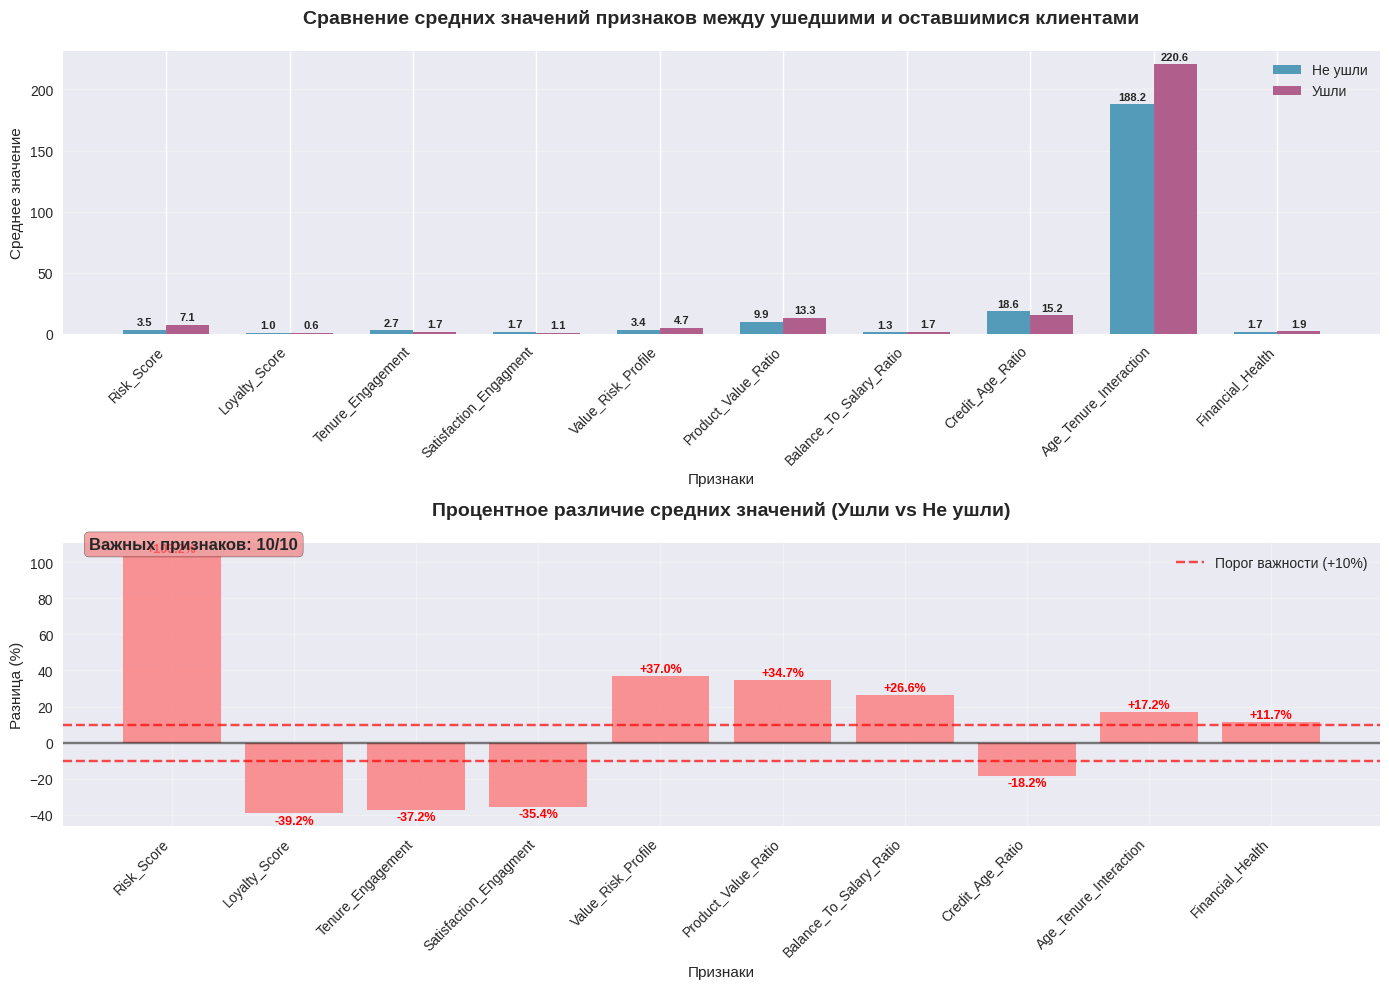

In [ ]:
final_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts','IsActiveMember', 'EstimatedSalary', 'Satisfaction Score','Geography', 'Gender', 'HasCrCard', 'Complain', 'Card Type', 'Points Earned','Risk_Score', 'Loyalty_Score','Tenure_Engagement','Satisfaction_Engagment','Value_Risk_Profile','Product_Value_Ratio','Balance_To_Salary_Ratio','Credit_Age_Ratio','Age_Tenure_Interaction','Financial_Health','Customer_Segment_Final']

strong_features = [f for f in final_features if f not in [
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
    'IsActiveMember', 'EstimatedSalary', 'Satisfaction Score',
    'Geography', 'Gender', 'HasCrCard', 'Complain', 'Card Type', 'Points Earned',
    'Customer_Segment_Final'
]]

features = []
stayed_means = []
left_means = []
diff_pct_values = []

for feature in strong_features:
    stayed_mean = df_clean[df_clean['Exited'] == 0][feature].mean()
    left_mean = df_clean[df_clean['Exited'] == 1][feature].mean()
    diff_pct = ((left_mean - stayed_mean) / stayed_mean) * 100

    features.append(feature)
    stayed_means.append(stayed_mean)
    left_means.append(left_mean)
    diff_pct_values.append(diff_pct)

    print(f"{feature:25} | Не ушли: {stayed_mean:7.2f} | Ушли: {left_mean:7.2f} | Разница: {diff_pct:+.1f}%")


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# График 1: Сравнение средних значений
x = np.arange(len(features))
width = 0.35

bars1 = ax1.bar(x - width/2, stayed_means, width, label='Не ушли', color='#2E86AB', alpha=0.8)
bars2 = ax1.bar(x + width/2, left_means, width, label='Ушли', color='#A23B72', alpha=0.8)

ax1.set_xlabel('Признаки')
ax1.set_ylabel('Среднее значение')
ax1.set_title('Сравнение средних значений признаков между ушедшими и оставшимися клиентами',
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(features, rotation=45, ha='right', fontsize=10)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

for i, (stay, left) in enumerate(zip(stayed_means, left_means)):
    ax1.text(i - width/2, stay + max(stayed_means)*0.01, f'{stay:.1f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax1.text(i + width/2, left + max(left_means)*0.01, f'{left:.1f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')

# График 2: Процентные различия
colors = ['#FF6B6B' if abs(diff) > 10 else '#4ECDC4' for diff in diff_pct_values]
bars = ax2.bar(features, diff_pct_values, color=colors, alpha=0.7)

ax2.axhline(y=10, color='red', linestyle='--', alpha=0.7, label='Порог важности (+10%)')
ax2.axhline(y=-10, color='red', linestyle='--', alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)

ax2.set_xlabel('Признаки')
ax2.set_ylabel('Разница (%)')
ax2.set_title('Процентное различие средних значений (Ушли vs Не ушли)',
              fontsize=14, fontweight='bold', pad=20)
ax2.set_xticklabels(features, rotation=45, ha='right', fontsize=10)
ax2.legend()
ax2.grid(True, alpha=0.3)

for bar, diff in zip(bars, diff_pct_values):
    height = bar.get_height()
    va = 'bottom' if height >= 0 else 'top'
    y_offset = 0.5 if height >= 0 else -0.8
    color = 'red' if abs(diff) > 10 else 'black'
    weight = 'bold' if abs(diff) > 10 else 'normal'

    ax2.text(bar.get_x() + bar.get_width()/2., height + y_offset,
            f'{diff:+.1f}%', ha='center', va=va,
            fontweight=weight, fontsize=9, color=color)

important_count = sum(1 for diff in diff_pct_values if abs(diff) > 10)
ax2.text(0.02, 0.98, f'Важных признаков: {important_count}/{len(features)}',
         transform=ax2.transAxes, fontsize=12, fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.7))

plt.tight_layout()
plt.show()


Оставим эти признаки, так как они имеют хороший результат!

#Разделение на признаки и целевую переменную

In [ ]:
X = df_clean.drop('Exited', axis=1)
y = df_clean['Exited']
print(f"Признаки: {X.shape}")
print(f"Целевая переменная: {y.shape}")
print(f"Всего признаков: {X.shape[1]}")

Признаки: (10000, 25)
Целевая переменная: (10000,)
Всего признаков: 25


#Разделение данных на выборки

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Подготовка данных для модели (предобработка)
Используем LabelEncoder для того, чтоы перевести текстовые данные в бинарную классификацию 1 и 0.

In [ ]:
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

label_encoders = {}

binary_categorical = ['Gender', 'HasCrCard']

for col in binary_categorical:
  le = LabelEncoder()
  X_train_encoded[col] = le.fit_transform(X_train_encoded[col])
  X_test_encoded[col] = le.transform(X_test_encoded[col])
  label_encoders[col] = le

multi_categorical = ['Geography', 'Card Type', 'Customer_Segment_Final']

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

ohe_train = ohe.fit_transform(X_train[multi_categorical])
ohe_test = ohe.fit_transform(X_test[multi_categorical])

feature_names = ohe.get_feature_names_out(multi_categorical)

ohe_train_df = pd.DataFrame(ohe_train, columns=feature_names, index=X_train.index)
ohe_test_df = pd.DataFrame(ohe_test, columns=feature_names, index=X_test.index)

for i, name in enumerate(feature_names[:10]):
  print(f'  {i + 1:2d}. {name}')
# Соединяем датафреймы
X_train_encoded = pd.concat([
    X_train_encoded.drop(columns=multi_categorical, axis=1),
    ohe_train_df
], axis=1)

X_test_encoded = pd.concat([
    X_test_encoded.drop(columns=multi_categorical, axis=1),
    ohe_test_df
], axis=1)


print(f"Размер X_train_encode = {X_train_encoded.shape}")
print(f"Размер X_test_encode = {X_test_encoded.shape}")

   1. Geography_France
   2. Geography_Germany
   3. Geography_Spain
   4. Card Type_DIAMOND
   5. Card Type_GOLD
   6. Card Type_PLATINUM
   7. Card Type_SILVER
   8. Customer_Segment_Final_credit_risk
   9. Customer_Segment_Final_low_balance_young
  10. Customer_Segment_Final_new_customer
Размер X_train_encode = (8000, 35)
Размер X_test_encode = (2000, 35)


#Масштабирование числовых признаков

In [ ]:
numerical_cols=[col for col in X_train_encoded.columns
                if col not in binary_categorical and not
                any(col.startswith(prefix) for prefix in multi_categorical)]
scaler = StandardScaler()
X_train_encoded[numerical_cols] = scaler.fit_transform(X_train_encoded[numerical_cols])
X_test_encoded[numerical_cols] = scaler.transform(X_test_encoded[numerical_cols])

print(f"X_train: {X_train_encoded.shape}")
print(f"X_test: {X_test_encoded.shape}")
print(f'Всего признаков: {X_train_encoded.shape[1]}')

X_train: (8000, 35)
X_test: (2000, 35)
Всего признаков: 35


#Обучение модели

Сначала я попробовал обучить модель со всеми признаками, но она мне дала результат в метриках под 100%. Это не нормальный результат, поэтому мы все же убираем такие признаки как 'Complain', 'Risk_Score', 'Complaint_Intensity', так как есть утечка данных.

In [ ]:

features_to_remove = [
    'Complain',           # Возможный data leakage
    'Risk_Score',         # Слишком сильный созданный признак
    'Complaint_Intensity' # Создан на основе Complain
]

X_train_encoded = X_train_encoded.drop(features_to_remove, axis=1, errors='ignore')
X_test_encoded = X_test_encoded.drop(features_to_remove, axis=1, errors='ignore')

lgbm_base = LGBMClassifier(
    random_state=42,
    verbosity=-1,
    class_weight='balanced'
)

param_distributions = {
    'n_enimators' : [100, 200, 300, 500],
    'learning_rate' : [0.01, 0.05, 0.1, 0.15, 0.2],
    'max_depth' : [-1, 5, 7, 10, 15],
    'num_leaves' : [20, 31, 50, 70, 100],
    'min_child_samples' : [10, 20, 30, 50],
    'subsample' : [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree' : [0.7, 0.8, 0.9, 1.0],
    'reg_aplha' : [0, 0.1, 0.5, 1.0],
    'reg_lambda' : [0, 0.1, 0.5, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_distributions,
    n_iter=100,
    scoring='roc_auc',
    verbose=1,
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_encoded, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5,
                   estimator=LGBMClassifier(class_weight='balanced',
                                            random_state=42, verbosity=-1),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.15,
                                                          0.2],
                                        'max_depth': [-1, 5, 7, 10, 15],
                                        'min_child_samples': [10, 20, 30, 50],
                                        'n_enimators': [100, 200, 300, 500],
                                        'num_leaves': [20, 31, 50, 70, 100],
                                        'reg_aplha': [0, 0.1, 0.5, 1.0],
                                        'reg_lambda': [0, 0.1, 0.5, 1.0],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [ ]:
best_params = random_search.best_params_

for param, value in best_params.items():
  print(f" {param:20}: {value}")

print(f"Лучший roc_auc: {random_search.best_score_:.4f}")

results_df = pd.DataFrame(random_search.cv_results_)
print(f"ТОП-5 комбинаций гиперпараметров:")
top_5_results = results_df.nlargest(5, 'mean_test_score')[['mean_test_score', 'params']]
for i, (_, row) in enumerate(top_5_results.iterrows(), 1):
    print(f"   {i}. ROC-AUC: {row['mean_test_score']:.4f}")

 subsample           : 0.9
 reg_lambda          : 0.1
 reg_aplha           : 0
 num_leaves          : 20
 n_enimators         : 300
 min_child_samples   : 10
 max_depth           : 10
 learning_rate       : 0.05
 colsample_bytree    : 0.7
Лучший roc_auc: 0.8616
ТОП-5 комбинаций гиперпараметров:
   1. ROC-AUC: 0.8616
   2. ROC-AUC: 0.8590
   3. ROC-AUC: 0.8590
   4. ROC-AUC: 0.8589
   5. ROC-AUC: 0.8572


In [ ]:
model_lgbm_tuned = random_search.best_estimator_
model_lgbm_tuned.fit(X_train_encoded, y_train)

y_pred_tuned = model_lgbm_tuned.predict(X_test_encoded)
y_pred_proba_tuned = model_lgbm_tuned.predict_proba(X_test_encoded)[:, 1]

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_pred_proba_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

In [ ]:
baseline_accuracy = y_test.value_counts(normalize=True).max()

print("ОСНОВНЫЕ МЕТРИКИ (С ТЮНИНГОМ):")
print(f"   Accuracy:    {accuracy_tuned:.4f}")
print(f"   ROC-AUC:     {roc_auc_tuned:.4f}")
print(f"   Precision:   {precision_tuned:.4f}")
print(f"   Recall:      {recall_tuned:.4f}")
print(f"   F1-Score:    {f1_tuned:.4f}")
print(f"   Baseline:    {baseline_accuracy:.4f}")

ОСНОВНЫЕ МЕТРИКИ (С ТЮНИНГОМ):
   Accuracy:    0.8155
   ROC-AUC:     0.8766
   Precision:   0.5326
   Recall:      0.7819
   F1-Score:    0.6336
   Baseline:    0.7960


#Матрица ошибок

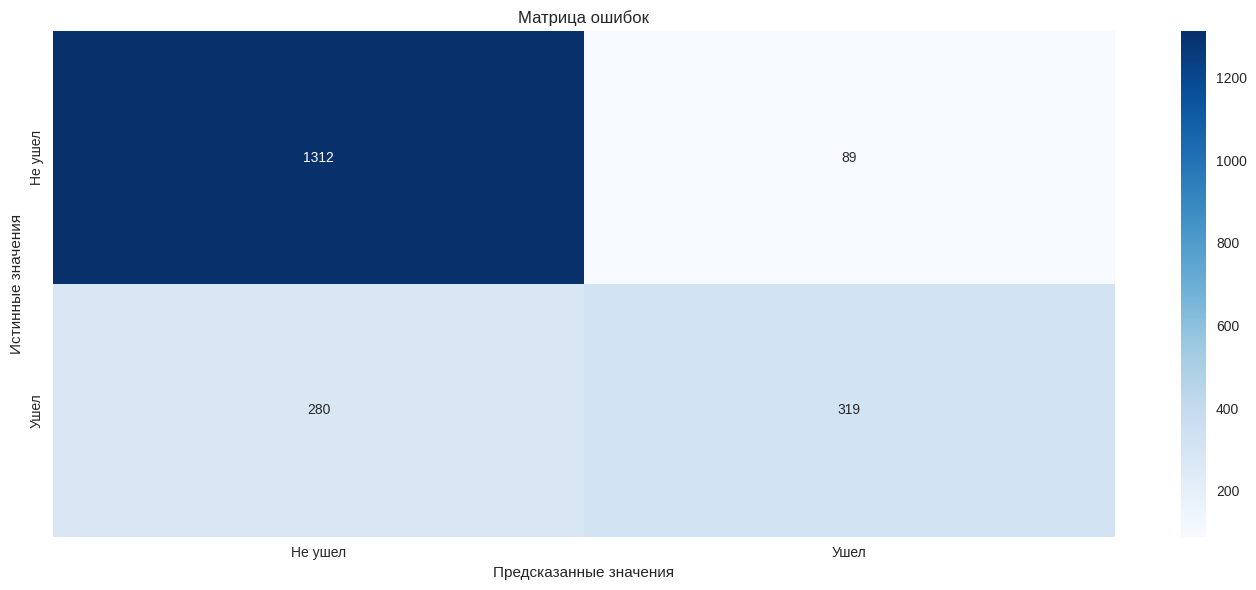

In [ ]:
cm = confusion_matrix(y_pred_tuned, y_test)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Не ушел', 'Ушел'],
            yticklabels=['Не ушел', 'Ушел']
            )
plt.title("Матрица ошибок")
plt.xlabel("Предсказанные значения")
plt.ylabel("Истинные значения")
plt.tight_layout()
plt.show()

#Визуализация метрик

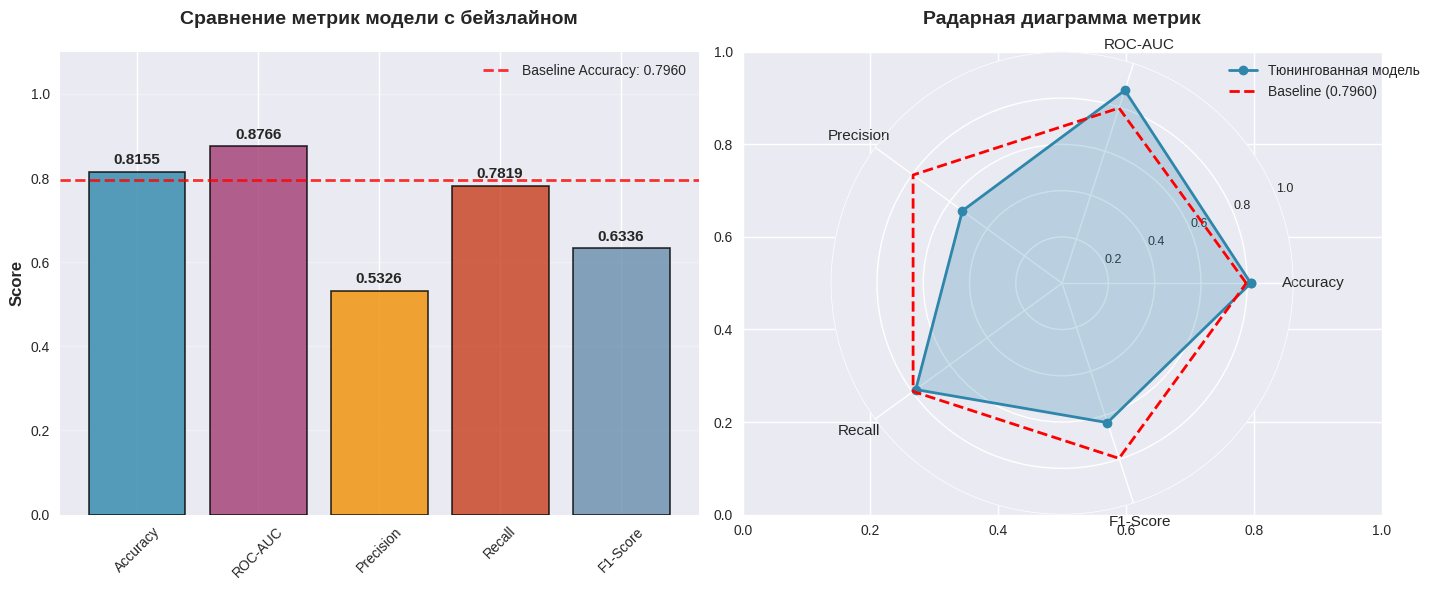

In [ ]:
metrics_names = ['Accuracy', 'ROC-AUC', 'Precision', 'Recall', 'F1-Score']
metrics_values = [accuracy_tuned, roc_auc_tuned, precision_tuned, recall_tuned, f1_tuned]
baseline = baseline_accuracy

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A8EAE']
bars = ax1.bar(metrics_names, metrics_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)

ax1.axhline(y=baseline, color='red', linestyle='--', linewidth=2,
            label=f'Baseline Accuracy: {baseline:.4f}', alpha=0.8)

for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{value:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('Сравнение метрик модели с бейзлайном', fontsize=14, fontweight='bold', pad=20)
ax1.set_ylim(0, 1.1)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='x', rotation=45)

angles = np.linspace(0, 2*np.pi, len(metrics_names), endpoint=False).tolist()
values = metrics_values + [metrics_values[0]]
angles += angles[:1]

ax2 = plt.subplot(122, polar=True)
ax2.plot(angles, values, 'o-', linewidth=2, label='Тюнингованная модель', color='#2E86AB')
ax2.fill(angles, values, alpha=0.25, color='#2E86AB')

baseline_values = [baseline] * len(angles)
ax2.plot(angles, baseline_values, '--', linewidth=2, label=f'Baseline ({baseline:.4f})', color='red')

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(metrics_names, fontsize=11)
ax2.set_ylim(0, 1)
ax2.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax2.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=9)
ax2.grid(True)
ax2.set_title('Радарная диаграмма метрик', fontsize=14, fontweight='bold', pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.show()

#Вывод
Изучив модель для предсказания оттока клиентов банка я добился таких значений метрик:\
ROC-AUC = 0.877 - Высокое качество классификации!\
Recall = 0.781 - Высокая полнота охвата оттока! Находим большинство уходящих.\
Precision = 0.533 - Приемлимая точность для дисбалансированных данных.\
Сначала я не мог определить как мне оценивать модель, какие метрики будут правильные для оценки, но я узнал что индустривальный стандарт для ROC-AUC в контексте нашей темы - 0.75 - 0.90. Это подтверждает отличную способность модели разделять классы.\
Работа была очень интересной, я попробовал создавать свои признаки, поработал с новой моделью, использовал большинство инструментов из прошлых работ для большей эффективности.

#Трудности во время создания модели
Я пробовал улучшить показатели модели с помощбю SMOTE, находил лучший порог для нее ~0.58, использовал ансамбли, но улучшений это все не давало. Я решил убрать этот код, так как он занимает очень много места, но никак не улучшает модель, а использование одной модели оказалось > чем использование ансамбля.\
В хоже выполнения этой работы я получил очень много опыта и обучился новым инструментам, а так же пришел к выводу, что не всегда использование ансамбля может поднять метрики.